# Assessment 2

## 1. Previous Descriptive Analysis and Results

In Assessment 1, a comprehensive exploratory data analysis of daily net retail sales from May 2000 to April 2003 was conducted, revealing significant weekly and yearly seasonality alongside high-amplitude volatility. A SARIMAX model was implemented to establish a statistical baseline for forecasting. While the model successfully captured the general sales level and the rhythmic weekly patterns, it struggled to accurately predict the magnitude of extreme sales spikes, resulting in a MAPE of 49.13%, an MAE of 121,217, and an RMSE of 149,494. Residual diagnostics indicated that the linear model had not fully extracted all available signals, with errors concentrated around extreme events. These results highlight the limitations of purely statistical linear models when confronted with non-linear, event-driven data, providing a clear rationale for transitioning to the machine learning approaches explored in this assessment.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data = pd.read_csv('07_Daily net retail sales. 5 May 2000 – 6 April 2003..csv')
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
data = data.set_index('date')
data = data.asfreq('D')

data = data.sort_index()

start_date = data.index.min()
end_date = data.index.max()
complete_date_range = pd.date_range(start=start_date, end=end_date, freq=data.index.freq)
is_index_complete = (data.index == complete_date_range).all()
print(f"Time Series Range: {start_date} to {end_date}\nIndex complete: {is_index_complete}")

Time Series Range: 2000-05-05 00:00:00 to 2003-04-06 00:00:00
Index complete: True


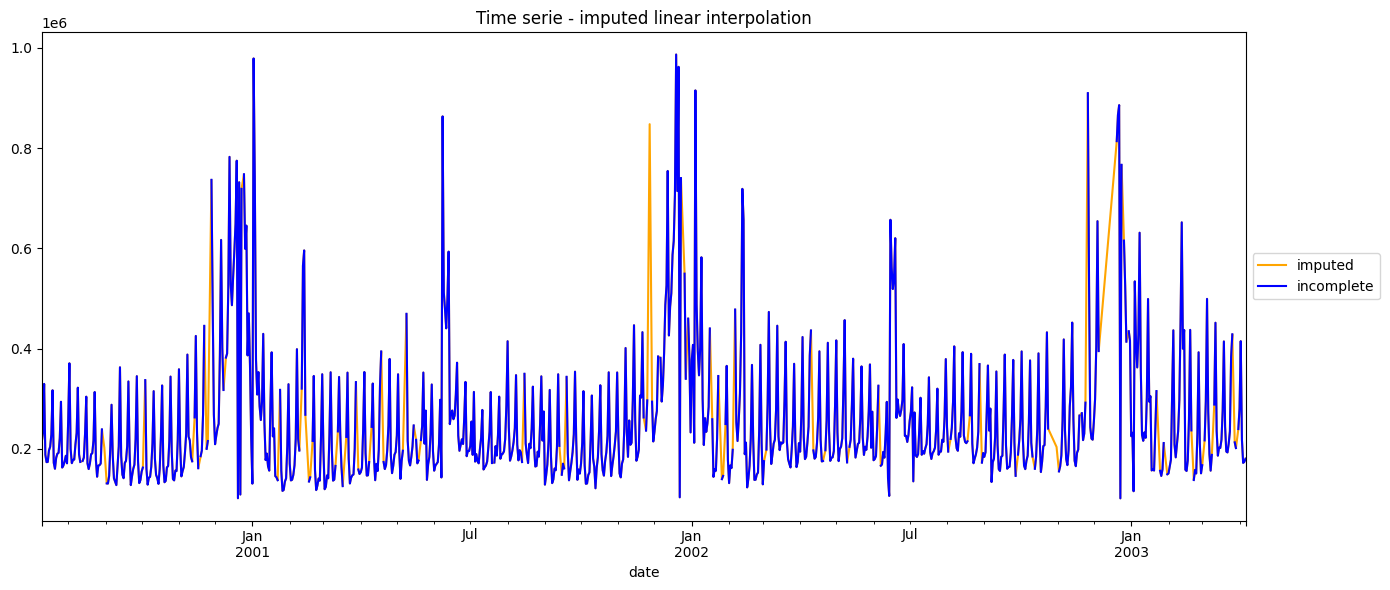

In [5]:
data_filtered = data[data.index >= '2000-07-10'].copy()
data_imputed = data_filtered.copy()
data_imputed['sales'] = data_imputed['sales'].interpolate(method="linear")
fig, ax = plt.subplots(figsize=(14, 6))

data_imputed['sales'].plot(ax=ax, label='imputed', color="orange")
data_filtered['sales'].plot(ax=ax, label="incomplete", color="blue")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Time serie - imputed linear interpolation")
plt.tight_layout() 
plt.show()

In [6]:
# Function to create features
def create_features(df):
    df = df.copy()
    
    # 1. Calendar Features
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(int)
    
    # 2. Lag Features (Historical sales values)
    # Yesterday, same day last week, same day 2 weeks ago
    df['lag_1'] = df['sales'].shift(1)
    df['lag_7'] = df['sales'].shift(7)
    df['lag_14'] = df['sales'].shift(14)
    
    # 3. Rolling Window Features (Capturing local trends)
    # 7-day and 30-day moving averages
    df['roll_mean_7'] = df['sales'].shift(1).rolling(window=7).mean()
    df['roll_std_7'] = df['sales'].shift(1).rolling(window=7).std()
    df['roll_mean_30'] = df['sales'].shift(1).rolling(window=30).mean()
    
    return df

# Apply feature engineering
df_ml = create_features(data)

# Drop rows with NaN values created by shifting/rolling
df_ml = df_ml.dropna()

display(df_ml.head())

,sales,day_of_week,month,quarter,is_weekend,lag_1,lag_7,lag_14,roll_mean_7,roll_std_7,roll_mean_30
date,,,,,,,,,,,
2000-08-09,321809.0,2,8,3,0,231602.0,370483.0,293742.0,219643.571429,69776.362604,210708.233333
2000-08-10,188905.0,3,8,3,0,321809.0,199677.0,162520.0,212690.142857,52534.488784,214333.933333
2000-08-11,173623.0,4,8,3,0,188905.0,171258.0,166537.0,211151.285714,53133.557562,212915.400000
2000-10-02,162525.0,0,10,4,0,154523.0,168215.0,176017.0,190183.285714,74148.542338,184595.033333
2000-11-03,144973.0,4,11,4,0,207862.0,139516.0,133233.0,196096.142857,78441.944620,193395.333333


In [7]:
# Split point: use the last 90 days for testing
split_date = df_ml.index.max() - pd.Timedelta(days=90)

train = df_ml.loc[df_ml.index <= split_date]
test = df_ml.loc[df_ml.index > split_date]

X_train = train.drop('sales', axis=1)
y_train = train['sales']
X_test = test.drop('sales', axis=1)
y_test = test['sales']

print(f"Training set size: {len(train)}")
print(f"Testing set size: {len(test)}")

Training set size: 87
Testing set size: 27


## 2. Data Preprocessing
• Process the data as necessary to use machine learning methods. Justify why each
preprocessing step was chosen.

## 3. Model Selection and Fitting
• Evaluate different machine learning models to determine the best fit for your specific
dataset.
• Outline your selection criteria and explain the rationale behind choosing your final model
over the alternatives.

### 3.1 Linear models

### 3.2 Tree Models

#### 3.2.1 Random Forest

#### 3.2.2 XGBoost

### 3.3 Prophet

### 3.4 Hybrid methods

#### 3.4.1 Residual Prediction

#### 3.4.2 Ensemble

## 4. Model Validation and Predictive Quality
• Evaluate the forecasting performance of your model using appropriate metrics and
validation scheme